<a href="https://colab.research.google.com/github/sashachereshnya-pixel/compling2025/blob/main/%D0%A7%D0%95%D0%A0%D0%95%D0%92%D0%98%D0%9A_%D0%94%D0%97_convnet_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3MOEYT_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3MOEYT_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3MOEYT_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


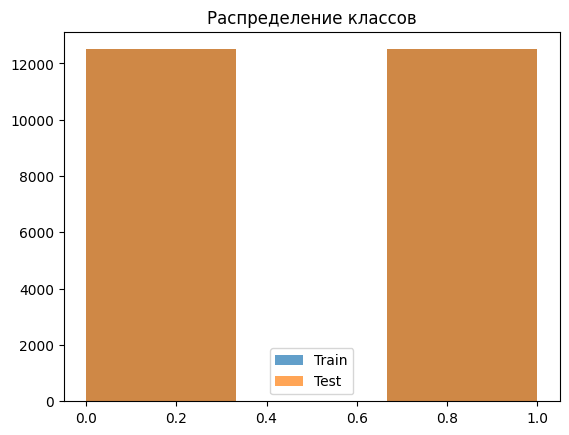

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
train_data, test_data = tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
x_train, y_train = [], []
x_test, y_test = [], []

for text, label in train_data:
    x_train.append(text.numpy().decode('utf-8'))
    y_train.append(label.numpy())

for text, label in test_data:
    x_test.append(text.numpy().decode('utf-8'))
    y_test.append(label.numpy())

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
# Используйте tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
# Преобразуйте данные в numpy массивы (x_train, y_train), (x_test, y_test)

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [2]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
vectorizer = keras.layers.TextVectorization(
    max_tokens=10000,  # 10_000 самых частых слов
    output_sequence_length=200,  # Максимальная длина последовательности
    output_mode='int'  # Целочисленные индексы слов
)
# vectorizer = keras.layers.TextVectorization(max_tokens=..., output_sequence_length=...)

# 4. Адаптируйте векторзатор на тренировочных текстах
vectorizer.adapt(x_train)
# vectorizer.adapt(...)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [3]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
model = keras.Sequential([
    # Входной слой с указанием формы (200,)
    keras.Input(shape=(200,), dtype='int32'),

    # Слой Embedding
    keras.layers.Embedding(
        input_dim=10000,  # размер словаря
        output_dim=128,   # размерность эмбеддингов
        input_length=200  # длина входных последовательностей
    ),

    # Сверточный слой Conv1D
    keras.layers.Conv1D(
        filters=64,       # 64 фильтра
        kernel_size=5,    # размер ядра 5
        activation='relu'
    ),

    # Слой пулинга
    keras.layers.GlobalMaxPooling1D(),

    # Полносвязный слой
    keras.layers.Dense(32, activation='relu'),

    # Выходной слой для бинарной классификации
    keras.layers.Dense(1, activation='sigmoid')
])

# model = keras.Sequential([...])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.6949 - loss: 0.5527 - precision: 0.6891 - recall: 0.7068 - val_accuracy: 0.8620 - val_loss: 0.3158 - val_precision: 0.8603 - val_recall: 0.8684
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.9289 - loss: 0.1944 - precision: 0.9279 - recall: 0.9299 - val_accuracy: 0.8594 - val_loss: 0.3298 - val_precision: 0.8936 - val_recall: 0.8198
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9911 - loss: 0.0469 - precision: 0.9929 - recall: 0.9892 - val_accuracy: 0.8620 - val_loss: 0.3956 - val_precision: 0.8879 - val_recall: 0.8325
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.9997 - loss: 0.0065 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 0.8658 - val_loss: 0.4372 - val_precision: 0.8732 - val_recall: 0.8597
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 1.0000 - loss: 9.7888e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8664 - val

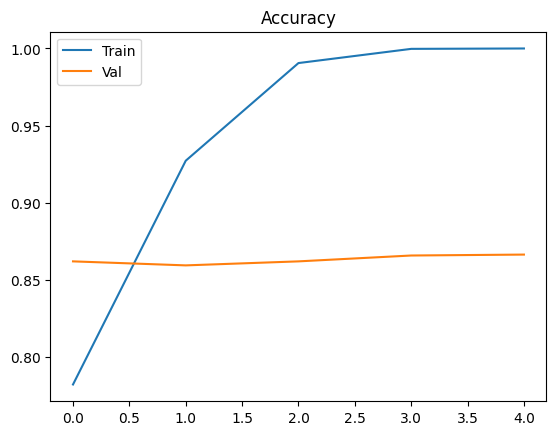

In [5]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
from tensorflow.keras.metrics import Precision, Recall
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# model.compile(...)

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
history = model.fit(
    x_train_vec,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
# history = model.fit(...)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [6]:
# 10. Оцените модель на тестовых данных
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec,
    y_test,
    verbose=0
)
# test_loss, test_acc, test_prec, test_rec = model.evaluate(...)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    # Подготавливаем данные для предсказания (добавляем размерность батча)
    input_data = x_test_vec[i:i+1]  # срез для сохранения размерности [1, 200]
    pred_prob = model.predict(input_data, verbose=0)
    pred_label = "POS" if pred_prob > 0.5 else "NEG"

    # Обрезаем текст до 50 символов для наглядности
    truncated_text = text[:50].replace('\n', ' ')
    # pred_prob = model.predict(...)
    # pred_label = "POS" if pred_prob > 0.5 else "NEG"
    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

Тестовая accuracy: 0.8666
Тестовая precision: 0.8605
Тестовая recall: 0.8752
There are films that make careers. For George Rome... | True: POS | Pred: POS (0.98)
A blackly comic tale of a down-trodden priest, Naz... | True: POS | Pred: POS (0.93)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the ... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some grav... | True: NEG | Pred: NEG (0.00)
As a former Erasmus student I enjoyed this film ve... | True: POS | Pred: POS (1.00)
My God, Ryan Gosling has made a lot of deep charac... | True: POS | Pred: POS (0.96)
This film just won the best film award at the Clev... | True: POS | Pred: POS (1.00)
The cast for this production of Rigoletto is excel... | True: POS | Pred: POS (1.00)
As long as you keep in mind that the production of... | True: NEG | Pred: NEG (0.07)
Every great once in a while, you stumble upon a mo... | True: POS | Pred: NEG (0.01)


## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Итоговая точность (accuracy) на тесте: 0.8666 (86.66%)

2. Наблюдения из истории обучения:

Точность на обучении (train accuracy) быстро растет от 0.6949 (эпоха 1) до 1.0000 (эпоха 5). Точность на валидации (val accuracy) стабилизируется около 0.86-0.87 начиная с эпохи 1. К 5-й эпохе train accuracy = 1.0000, а val accuracy = 0.8664

Явные признаки переобучения:

Значительный разрыв между кривыми:

Разница в точности составляет 0.1336 (13.36%) к 5-й эпохе - это классический случай сильного переобучения

Динамика обучения:

Train accuracy постоянно и быстро растет до совершенства (1.0). В свою очередь, Val accuracy достигает плато уже на 1-й эпохе (0.8620) и почти не улучшается.Также после 1-й эпохи модель только запоминает обучающие данные, не улучшая обобщение

Поведение функции потерь:

Train loss снижается до 0.00097888 (почти 0). Val loss увеличивается с 0.3158 до 0.4734. Рост val loss при снижении train loss - явный признак переобучения

Вывод: Сильное переобучение присутствует

Причины переобучения в данной модели:

- Отсутствие регуляризации: Нет Dropout слоев или L2-регуляризации

- Высокая сложность модели: Для относительно небольшого датасета (25K обучающих примеров)

- Избыточная емкость модели: Модель слишком хорошо запоминает обучающие данные
3.
- Неполный контекст: Текст обрезан на слове "mo..." - это может быть: "movie" (фильм) - нейтральное слово, "monstrosity" (чудовищность) - негативное слово, "masterpiece" (шедевр) - позитивное слово. Без полного контекста сложно судить о тональности.

- Лингвистическая сложность:

"Every great once in a while" - нестандартная конструкция. Возможно, автор хотел сказать "Every once in a great while" (очень редко). Модель может интерпретировать "great" как положительное, но "once in a while" (время от времени) как нерегулярность/недостаток

- Семантика глагола "stumble upon":

"stumble upon" означает "наткнуться случайно". Это может означать неожиданную находку (позитивно) или случайность без намерения (нейтрально/негативно). Модель могла сфокусироваться на слове "stumble" (спотыкаться), которое имеет негативную коннотацию

- Проблема с обучающими данными:

Такая специфическая фраза могла редко встречаться в обучающей выборке, и модель не научилась корректно интерпретировать подобные идиоматические выражения

- Высокая уверенность модели в ошибке:

Вероятность 0.01 показывает, что модель практически уверена, что это негативный отзыв. Это может указывать на то, что в полном тексте присутствуют слова, которые модель сильно ассоциирует с негативными отзывами